In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.analysis import (
    order_parameter, 
    compute_effective_coupling, 
    avg_effective_coupling,
    functional_connectivity,
    R_link,
)
from kuramoto.adjoint import (
    grads_final_R, 
    grads_mean_R, 
    node_importance_from_gradK, 
    grads_final_R_alpha,
    grads_mean_R_alpha,
)
from kuramoto.plotting import plot_2d, plot_coupling_matrix
from kuramoto.network import (
    create_cortical_graph,
    plot_cortical_graph,
    get_degree,
    plot_graph_metrics
)

from jax import numpy as jnp

SUPTITLE_SIZE = 20
plt.rcParams.update({
    "font.size": 14,
    "figure.titlesize": 20,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

SEED = 42
grid_shape = (12, 12)
T_END = 10.0
dt = 0.01

RNG = np.random.default_rng(SEED)


n_rows, n_cols = grid_shape

group_ids = np.zeros((n_rows, n_cols), dtype=int)
group_ids[n_rows // 2 :, :] = 1 # Top half is group 1, bottom half is group 0
group_ids[n_rows // 2 -2: n_rows // 2 +2, n_cols // 2 -2: n_cols // 2 +2] = 2 # 3x3 block in center is group 2
group_ids = group_ids.ravel().tolist()

components = [
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[0],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="within",
    ),
    KernelComponentConfig( # Fully connected coupling from group 2 to groups 0 and 1
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="outgoing",
    ),
    KernelComponentConfig( 
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="incoming",
    ),
    KernelComponentConfig( # weak one way coupling from group 1 to group 0
        kernel="gaussian",
        base_strength=0.2,
        kernel_params={"sigma": 2.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="custom",
        to_node_groups=[0],
    ),
]

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        kernel="gaussian",
        base_strength=1.0,
        radius=4.0,
        mode="spatial",
        components=components,
        group_ids=group_ids,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

# Run simulation
results = sim.run((0, T_END), dt, rng=RNG)

# Visualize base network
G = create_cortical_graph(sim)

plot_cortical_graph(G, layout="grid")


# Postprocess
R_list, _ = order_parameter(results['theta'])

fig,ax = plt.subplots(figsize=(10,5))
ax.plot(results['ts'], R_list, linewidth=1.5)
ax.set_xlabel("Time")
ax.set_ylabel("Global Order R(t)")
ax.set_title("Synchronization behavior of demo simulation")
ax.grid(True)

### 1) Network theory metrics

Create derived graphs and evaluate relevant centrality / important metrics.

In [ ]:
from matplotlib.colors import Normalize, CenteredNorm,TwoSlopeNorm

# K_eff_T = compute_effective_coupling(sim.results["theta"][-1], sim.coupling.K)
K_eff_avg = avg_effective_coupling(sim.results["theta"], sim.coupling.K)

K_diff = sim.coupling.K - K_eff_avg

fig,ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
im = ax[0].imshow(K_eff_avg, norm=Normalize(vmin=0, vmax=np.max(K_eff_avg)), cmap="viridis")
ax[0].set_title("K_eff_avg")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)


if np.min(K_diff) < 0:
    norm=TwoSlopeNorm(vmin=np.min(K_diff),vcenter=0.0,vmax=np.max(K_diff))
    cmap="bwr"
else:
    norm=Normalize(vmin=0,vmax=np.max(K_diff))
    cmap="Reds"
im = ax[1].imshow(K_diff, norm=norm, cmap=cmap)
ax[1].set_title("K - K_eff_avg")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
fig.suptitle("Average effective coupling matrix (K_eff_avg) vs Coupling matrix (K)")

G_eff = create_cortical_graph(K_eff_avg, omega=sim.params.omega)

plot_cortical_graph(G_eff, layout="grid")

In [ ]:
# Functional connectivity matrix
C_avg = functional_connectivity(sim.results["theta"], dt=dt)

# Compare with normalized coupling matrix
K_norm = sim.coupling.K / np.max(sim.coupling.K) # [0,1]

fig,ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
im = ax[0].imshow(C_avg, norm=Normalize(vmin=0,vmax=1), cmap="viridis")
ax[0].set_title("C_avg")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(C_avg-K_norm, norm=CenteredNorm(), cmap="bwr")
ax[1].set_title("C_avg - normalized K")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
fig.suptitle("Functional connectivity matrix (C_avg) vs normalized coupling matrix (K_norm)")

G_C_avg = create_cortical_graph(C_avg, omega=sim.params.omega)

plot_cortical_graph(G_C_avg,layout="grid")

In [ ]:
fig,axs = plt.subplots(3,4,figsize=(16,12))

plot_graph_metrics(G=G,grid_shape=grid_shape,axs=axs[0,:])
plot_graph_metrics(G=G_eff,grid_shape=grid_shape,axs=axs[1,:])
plot_graph_metrics(G=G_C_avg,grid_shape=grid_shape,axs=axs[2,:])

axs[0,0].set_ylabel("Base Coupling Graph")
axs[1,0].set_ylabel("Effective Coupling Graph")
axs[2,0].set_ylabel("Functional Connectivity Graph")

### 2) Adjoint metrics

In [ ]:
t0, t1 = 0.0, T_END
ts = jnp.arange(t0, t1 + dt / 2, dt)
ts = ts[ts <= t1]

g = grads_final_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=[T_END])
g_avg = grads_mean_R(sim.params, sim.theta0, t0=0.0, t1=T_END, dt=dt, ts=ts)

dR_dK = np.asarray(g.K)
dR_domega = np.asarray(g.omega)

dR_dK_avg = np.asarray(g_avg.K)
dR_domega_avg = np.asarray(g_avg.omega)

dR_domega_2d = sim.grid.unflatten(dR_domega)
dR_domega_avg_2d = sim.grid.unflatten(dR_domega_avg)

# Statistics
print(f"  max |dR/dK| = {float(np.max(np.abs(dR_dK))):.6e}")
print(f"  max |dR/domega| = {float(np.max(np.abs(dR_domega))):.6e}")
print(f"  max |dR/dK| (averaged) = {float(np.max(np.abs(dR_dK_avg))):.6e}")
print(f"  max |dR/domega| (averaged) = {float(np.max(np.abs(dR_domega_avg))):.6e}")

# Plot coupling matrix
fig, axs = plt.subplots(2,2,figsize=(10,8))
axs = axs.ravel()

im = axs[0].imshow(dR_dK, cmap="bwr")
axs[0].set_title("dRf/dK")
fig.colorbar(im,ax=axs[0],fraction=0.046, pad=0.04)

im = axs[1].imshow(dR_domega_2d, cmap="bwr")
axs[1].set_title("dRf/domega0")
fig.colorbar(im,ax=axs[1],fraction=0.046, pad=0.04)  

im = axs[2].imshow(dR_dK_avg, cmap="bwr")
axs[2].set_title("dRm/dK (averaged)")
fig.colorbar(im,ax=axs[2],fraction=0.046, pad=0.04)

im = axs[3].imshow(dR_domega_avg_2d, cmap="bwr")
axs[3].set_title("dRm/domega0 (averaged)")
fig.colorbar(im,ax=axs[3],fraction=0.046, pad=0.04)
fig.suptitle("Adjoint gradients")

  max |dRf/dalpha|         = 2.463365e-03
  max |dRm/dalpha|         = 5.458221e-02
  max |dRlink/dalpha|      = 8.283896e-02
  max |IG_dRm/dalpha|      = 2.971566e-02
  max |IG_dRlink/dalpha|   = 1.380021e-02


Text(0.5, 0.98, 'Adjoint lesion metrics: linearized (top) vs Integrated Gradients (bottom)')

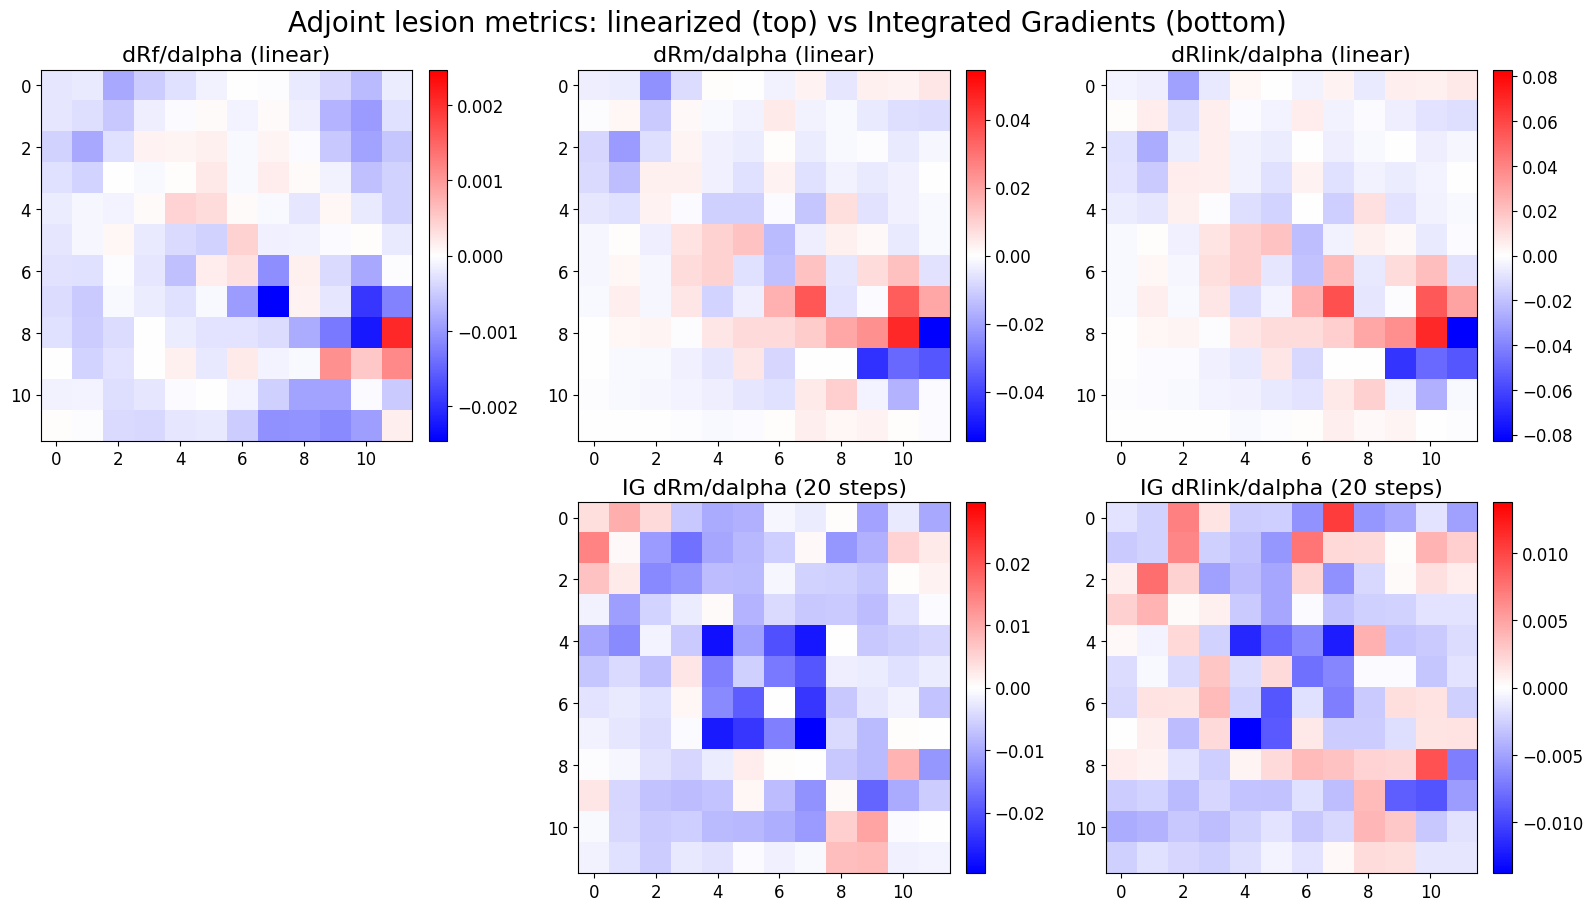

In [15]:
from kuramoto.adjoint import grads_mean_r_link_alpha, ig_mean_R_alpha, ig_mean_r_link_alpha
from matplotlib.colors import CenteredNorm

N_IG_STEPS = 20  # quadrature steps for Integrated Gradients

alpha0 = jnp.zeros((sim.grid.N,), dtype=sim.params.K.dtype)
dRf_dalpha = grads_final_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)
dRm_dalpha = grads_mean_R_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)
dR_link_dalpha = grads_mean_r_link_alpha(sim.params, alpha0, sim.theta0, t0, t1, dt, ts=ts)

# Integrated Gradients: nonlinear path integral from alpha=0 -> ones (full lesion)
alpha_target = jnp.ones(sim.grid.N, dtype=sim.params.K.dtype)
IG_dRm_dalpha = ig_mean_R_alpha(sim.params, alpha_target, sim.theta0, t0, t1, dt, ts=ts, n_steps=N_IG_STEPS)
IG_dR_link_dalpha = ig_mean_r_link_alpha(sim.params, alpha_target, sim.theta0, t0, t1, dt, ts=ts, n_steps=N_IG_STEPS)

# Statistics
print(f"  max |dRf/dalpha|         = {float(np.max(np.abs(dRf_dalpha))):.6e}")
print(f"  max |dRm/dalpha|         = {float(np.max(np.abs(dRm_dalpha))):.6e}")
print(f"  max |dRlink/dalpha|      = {float(np.max(np.abs(dR_link_dalpha))):.6e}")
print(f"  max |IG_dRm/dalpha|      = {float(np.max(np.abs(IG_dRm_dalpha))):.6e}")
print(f"  max |IG_dRlink/dalpha|   = {float(np.max(np.abs(IG_dR_link_dalpha))):.6e}")

# ── Plot: linearized metrics (row 0) vs IG metrics (row 1) ───────────────────
fig, axs = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

im = axs[0, 0].imshow(dRf_dalpha.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
axs[0, 0].set_title("dRf/dalpha (linear)")
fig.colorbar(im, ax=axs[0, 0], fraction=0.046, pad=0.04)

im = axs[0, 1].imshow(dRm_dalpha.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
axs[0, 1].set_title("dRm/dalpha (linear)")
fig.colorbar(im, ax=axs[0, 1], fraction=0.046, pad=0.04)

im = axs[0, 2].imshow(dR_link_dalpha.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
axs[0, 2].set_title("dRlink/dalpha (linear)")
fig.colorbar(im, ax=axs[0, 2], fraction=0.046, pad=0.04)

axs[1, 0].set_visible(False)  # no IG equivalent for Rf

im = axs[1, 1].imshow(IG_dRm_dalpha.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
axs[1, 1].set_title(f"IG dRm/dalpha ({N_IG_STEPS} steps)")
fig.colorbar(im, ax=axs[1, 1], fraction=0.046, pad=0.04)

im = axs[1, 2].imshow(IG_dR_link_dalpha.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
axs[1, 2].set_title(f"IG dRlink/dalpha ({N_IG_STEPS} steps)")
fig.colorbar(im, ax=axs[1, 2], fraction=0.046, pad=0.04)

fig.suptitle("Adjoint lesion metrics: linearized (top) vs Integrated Gradients (bottom)")

In [ ]:
# Verify lesion grads with finite difference
from kuramoto.adjoint import finite_diff_dJ_dalpha, mean_order_parameter, final_order_parameter

test_nodes = [0, sim.grid.N // 2, sim.grid.N - 1]

print("=== Final R ===")
for i in test_nodes:
    fd = finite_diff_dJ_dalpha(sim, final_order_parameter, i, t0, t1, dt, ts=jnp.array([t1]))
    ad = float(dRf_dalpha[i])
    print(f"  node {i:3d}:  AD={ad: .6e}  FD={fd: .6e}  ratio={ad/fd if abs(fd)>1e-15 else float('nan'):.4f}")

print("=== Mean R ===")
for i in test_nodes:
    fd = finite_diff_dJ_dalpha(sim, mean_order_parameter, i, t0, t1, dt, ts=ts)
    ad = float(dRm_dalpha[i])
    print(f"  node {i:3d}:  AD={ad: .6e}  FD={fd: .6e}  ratio={ad/fd if abs(fd)>1e-15 else float('nan'):.4f}")

### Post processed adjoint metrics

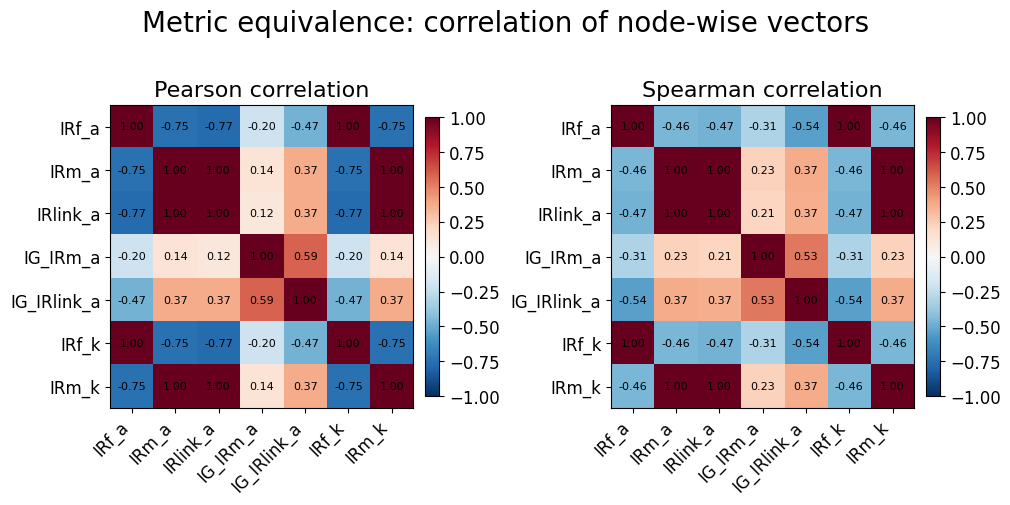

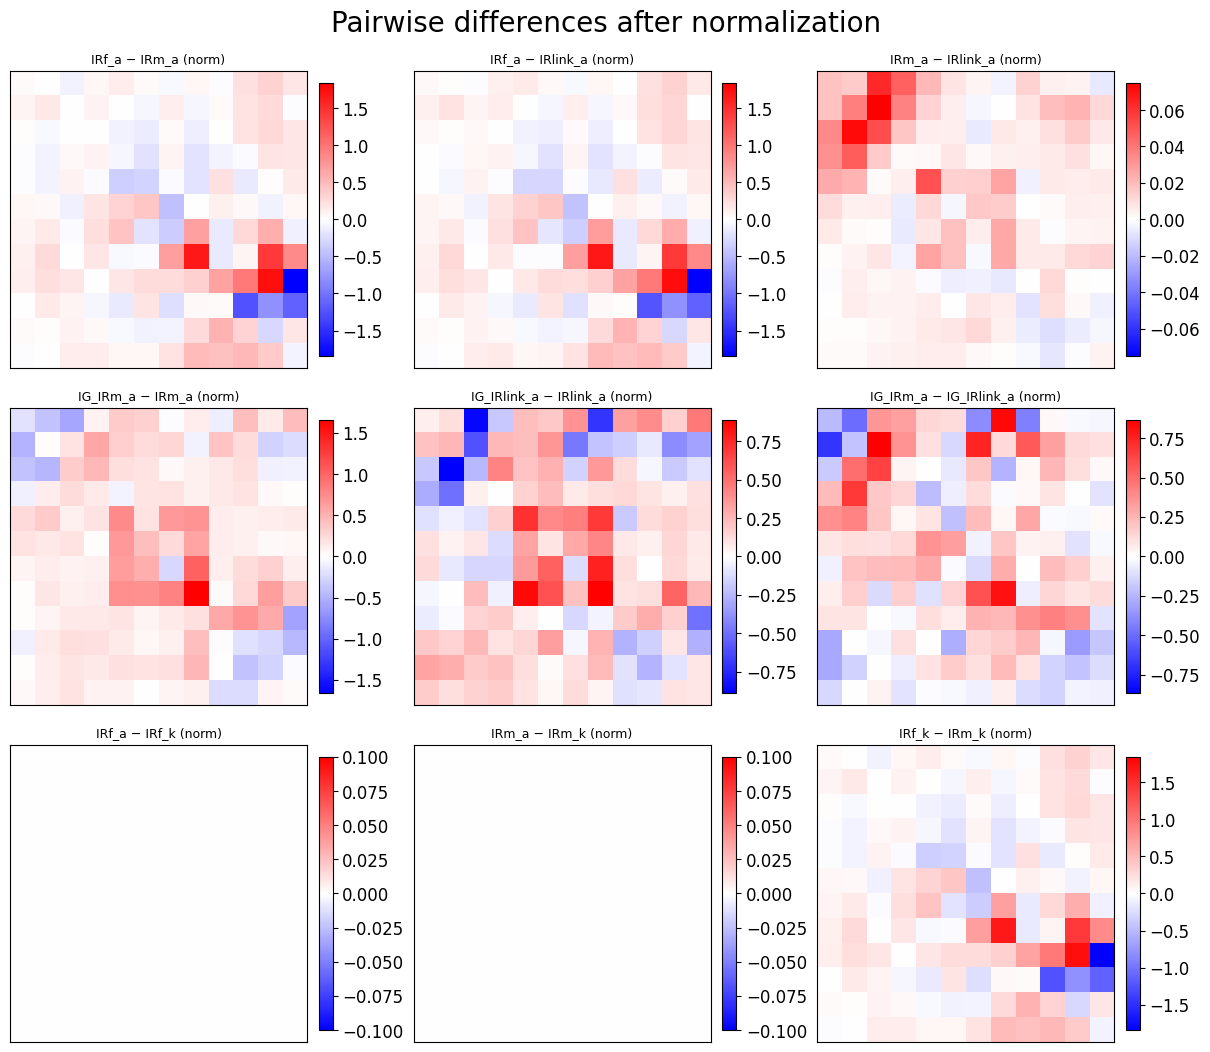

In [17]:
from matplotlib.colors import CenteredNorm
from scipy.stats import spearmanr

# Convert raw gradients to node importance metrics
IRf_k = node_importance_from_gradK(sim.params.K, g.K)
IRm_k = node_importance_from_gradK(sim.params.K, g_avg.K)

# Change sign since increasing alpha results in negative grad if node is important
IRf_a = -dRf_dalpha
IRm_a = -dRm_dalpha
IRlink_a = -dR_link_dalpha
IG_IRm_a = -IG_dRm_dalpha
IG_IRlink_a = -IG_dR_link_dalpha

vecs = {
    "IRf_a": IRf_a,
    "IRm_a": IRm_a,
    "IRlink_a": IRlink_a,
    "IG_IRm_a": IG_IRm_a,
    "IG_IRlink_a": IG_IRlink_a,
    "IRf_k": IRf_k,
    "IRm_k": IRm_k,
}
names = list(vecs.keys())

# Pearson correlation matrix (linear agreement)
X = np.column_stack([vecs[k] for k in names])
R_pearson = np.corrcoef(X, rowvar=False)

# Spearman correlation matrix (monotonic agreement; good for "same ranking?")
R_spear = np.ones((len(names), len(names)))
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        rho, _ = spearmanr(vecs[names[i]], vecs[names[j]])
        R_spear[i, j] = R_spear[j, i] = rho

fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
im0 = ax[0].imshow(R_pearson, vmin=-1, vmax=1, cmap="RdBu_r")
ax[0].set_xticks(range(len(names)))
ax[0].set_yticks(range(len(names)))
ax[0].set_xticklabels(names, rotation=45, ha="right")
ax[0].set_yticklabels(names)
ax[0].set_title("Pearson correlation")
for i in range(len(names)):
    for j in range(len(names)):
        ax[0].text(j, i, f"{R_pearson[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(R_spear, vmin=-1, vmax=1, cmap="RdBu_r")
ax[1].set_xticks(range(len(names)))
ax[1].set_yticks(range(len(names)))
ax[1].set_xticklabels(names, rotation=45, ha="right")
ax[1].set_yticklabels(names)
ax[1].set_title("Spearman correlation")
for i in range(len(names)):
    for j in range(len(names)):
        ax[1].text(j, i, f"{R_spear[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.suptitle("Metric equivalence: correlation of node-wise vectors", y=1.02)
plt.show()

# --- Normalized spatial patterns and pairwise differences (scale-free)
def safe_norm(v):
    m = np.max(np.abs(v))
    return v / m if m > 0 else v

IRf_a_norm = safe_norm(IRf_a)
IRm_a_norm = safe_norm(IRm_a)
IRlink_a_norm = safe_norm(IRlink_a)
IG_IRm_a_norm = safe_norm(IG_IRm_a)
IG_IRlink_a_norm = safe_norm(IG_IRlink_a)
IRf_k_norm = safe_norm(IRf_k)
IRm_k_norm = safe_norm(IRm_k)

pairs = [
    # Linear adjoint inter-comparisons
    (IRf_a_norm - IRm_a_norm, "IRf_a − IRm_a (norm)"),
    (IRf_a_norm - IRlink_a_norm, "IRf_a − IRlink_a (norm)"),
    (IRm_a_norm - IRlink_a_norm, "IRm_a − IRlink_a (norm)"),
    # IG vs linearized (key comparison)
    (IG_IRm_a_norm - IRm_a_norm, "IG_IRm_a − IRm_a (norm)"),
    (IG_IRlink_a_norm - IRlink_a_norm, "IG_IRlink_a − IRlink_a (norm)"),
    # IG inter-comparison
    (IG_IRm_a_norm - IG_IRlink_a_norm, "IG_IRm_a − IG_IRlink_a (norm)"),
    # K-derived
    (IRf_a_norm - IRf_k_norm, "IRf_a − IRf_k (norm)"),
    (IRm_a_norm - IRm_k_norm, "IRm_a − IRm_k (norm)"),
    (IRf_k_norm - IRm_k_norm, "IRf_k − IRm_k (norm)"),
]

ncols = 3
nrows = int(np.ceil(len(pairs) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), constrained_layout=True)
axs = np.atleast_1d(axs).ravel()
for ax, (arr, title) in zip(axs, pairs):
    im = ax.imshow(arr.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for ax in axs[len(pairs) :]:
    ax.set_visible(False)
plt.suptitle("Pairwise differences after normalization")
plt.show()

## Findings
1) IJ_a = fused IJ_k
This makes sense algebraically

2) Sign flip in IRf and IRm
This is no a bug and is a function of the actual network

3) Finite difference validates autgrad implementation